In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (3.6, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import os
import torch
import pickle
from pathlib import Path
import numpy as np
from jarvis.utils import tqdm, array2tensor, tensor2array

from hexarena import STORE_DIR
FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from matplotlib import colormaps
pi_colors = colormaps['Set1'].colors
box_colors = ['blue', 'green', 'red']

# Learn belief dynamics

In [2]:
subject_id = 'marco'

with open(STORE_DIR/f'{subject_id}.mean.beliefs.pkl', 'rb') as f:
    saved = array2tensor(pickle.load(f))

block_infos = saved['block_infos']
if subject_id in ['marco', 'dylan']:
    kappas = [0.01, 0.1]
if subject_id in ['viktor']:
    kappas = [0.01, 0.2]
block_ids = []
for block_id, block_info in saved['block_infos'].items():
    if block_info['kappa'] in kappas:
        block_ids.append(block_id)
inputs = {block_id: torch.atanh(2*saved['inputs'][block_id]-1) for block_id in block_ids}
actions = saved['actions']
n_actions = saved['n_actions']

In [3]:
from torch.utils.data import TensorDataset, random_split, DataLoader

bs_t, as_t, bs_tp1 = [], [], []
for block_id in block_ids:
    bs_t.append(inputs[block_id][:-1])
    as_t.append(actions[block_id][:-1])
    bs_tp1.append(inputs[block_id][1:])
bs_t = torch.cat(bs_t)
as_t = torch.cat(as_t)
bs_tp1 = torch.cat(bs_tp1)

dsets = {}
dsets['train'], dsets['val'] = random_split(TensorDataset(bs_t, as_t, bs_tp1), [0.8, 0.2])
loaders = {
    'train': DataLoader(dsets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(dsets['val'], batch_size=100, shuffle=False),
}

In [4]:
import torch.nn as nn
from jarvis.utils import create_mlp_layers
from jarvis.config import Config

class BeliefModel(nn.Module):
    r"""Class for belief dynamics

    Args
    ----
    n_boxes:
        Number of food boxes.
    encoder:
        Variational encoder that outputs both mean and variance in z-space.
    decoder:
        Decoder that converts samples in z-space to unbounded belief representation.
    
    """

    def __init__(self,
        n_boxes: int = 3,
        z_dim: int = 8,
        encoder: dict|None = None,
        decoder: dict|None = None,
    ):
        super().__init__()
        self.n_boxes = n_boxes
        self.z_dim = z_dim
        self.encoder = nn.Sequential(*create_mlp_layers(
            2*n_boxes+1, 2*z_dim, **Config(encoder),
        ))
        self.decoder = nn.Sequential(*create_mlp_layers(
            z_dim, n_boxes, **Config(decoder),
        ))

        self.rng = np.random.default_rng()

    def encode(self, beliefs, actions):
        inputs = torch.cat([beliefs, nn.functional.one_hot(actions, self.n_boxes+1)], dim=1)
        outs = self.encoder(inputs)
        mus = outs[:, :self.z_dim]
        log_sigmas = outs[:, self.z_dim:]
        return mus, log_sigmas

    def sample(self, mus, log_sigmas, n_scale = 1.):
        ns = torch.tensor(self.rng.normal(loc=0, scale=n_scale, size=mus.shape)).to(mus)
        zs = mus+ns*torch.exp(log_sigmas)
        z_losses = (-0.5*ns.pow(2)-log_sigmas+0.5*zs.pow(2)).sum(dim=1)
        return zs, z_losses

    def decode(self, zs):
        next_beliefs = self.decoder(zs)
        return next_beliefs

    @classmethod
    def get_kl_losses(cls, preds, targets):
        ps = (torch.tanh(targets)+1)/2
        qs = (torch.tanh(preds)+1)/2
        kl_losses = (ps*(torch.log(ps)-torch.log(qs))+(1-ps)*(torch.log(1-ps)-torch.log(1-qs))).sum(dim=1)
        return kl_losses

    def forward(self, beliefs, actions, n_scale = 1.):
        mus, log_sigmas = self.encode(beliefs, actions)
        zs, z_losses = self.sample(mus, log_sigmas, n_scale)
        next_beliefs = self.decode(zs)
        return zs, z_losses, next_beliefs

def get_losses(model, batch):
    device = next(iter(model.parameters())).device
    bs_t, as_t, bs_tp1 = batch
    _, z_losses, preds = model(bs_t.to(device), as_t.to(device))
    kl_losses = model.get_kl_losses(preds, bs_tp1.to(device))
    losses = torch.stack([kl_losses, z_losses], dim=1)
    return losses

def evaluate(model, loader):
    model.eval()
    losses = []
    for batch in loader:
        with torch.no_grad():
            losses.append(get_losses(model, batch).cpu())
    losses = torch.cat(losses).mean(dim=0)
    return losses

def train_one_epoch(model, loader, optimizer, alphas):
    model.train()
    for batch in loader:
        losses = get_losses(model, batch).mean(dim=0)
        loss = (losses*alphas).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [5]:
from torch.optim import SGD

model = BeliefModel()
model_pth = STORE_DIR/f'{subject_id}.belief.model.pkl'
if model_pth.exists():
    with open(model_pth, 'rb') as f:
        model.load_state_dict(array2tensor(pickle.load(f)))
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    optimizer = SGD(model.parameters(), lr=1e-3, momentum=0.9)
   
    z_reg = 0.001
    alphas = torch.tensor([1, z_reg]).to(device)
    
    n_epochs = 100
    losses = []
    with tqdm(total=n_epochs, unit='epoch') as pbar:
        for _ in range(n_epochs):
            train_one_epoch(model, loaders['train'], optimizer, alphas)
            losses.append(evaluate(model, loaders['val']))
            pbar.set_description('[KL {:.3f}][Z {:.3f}]'.format(*losses[-1]))
            pbar.update()
    losses = torch.stack(losses)

    with open(model_pth, 'wb') as f:
        pickle.dump(tensor2array(model.state_dict()), f)

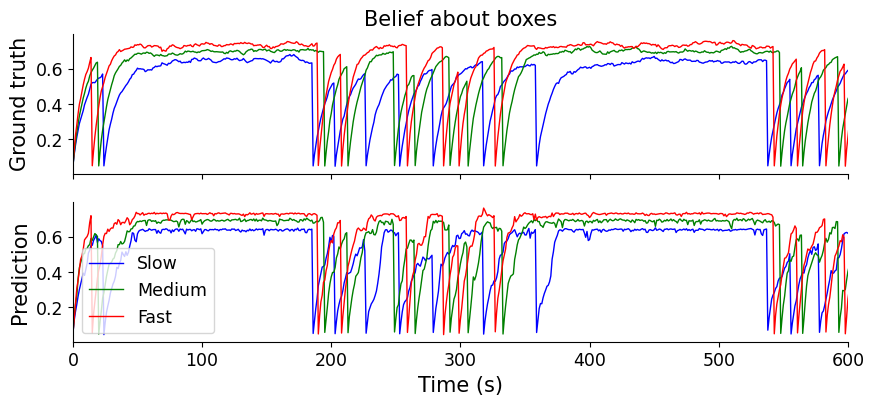

In [6]:
model.cpu()

block_id = block_ids[rng.choice(len(block_ids))]
belief = inputs[block_id][0][None]
beliefs = [belief]
for t, action in enumerate(actions[block_id]):
    with torch.no_grad():
        _, _, belief = model(belief, action[None], n_scale=1.)
    beliefs.append(belief)
preds = (torch.tanh(torch.cat(beliefs)[:-1])+1)/2
targets = (torch.tanh(inputs[block_id])+1)/2

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, sharey=True)
ax = axes[0]
for i, color in enumerate(box_colors):
    ax.plot(targets[:, i], color=color, linewidth=1)
ax.set_ylabel('Ground truth')
ax.set_title('Belief about boxes')
ax = axes[1]
lines = []
for i, color in enumerate(box_colors):
    h, = ax.plot(preds[:, i], color=color, linewidth=1)
    lines.append(h)
ax.legend(lines, ['Slow', 'Medium', 'Fast'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Prediction')
ax.set_xlim([0, 600])
fig.savefig(FIG_DIR/f'{subject_id}.belief.model.svg')

# Examine HMM trained by scripts

HMMs can be trained by `scripts.identify_policies`, below is how to fetch and examine the results

In [7]:
from hexarena.scripts.identify_policies import create_manager

manager = create_manager(subject_id)
# manager.export_tar(f'store/{subject_id}.policies.tar.gz')

In [8]:
n_policies_list = [1, 2, 3, 4, 5, 6, 7, 8]
p_stay = 0.95
lls, best_keys = {}, {}
for n_policies in n_policies_list:
    for belief_aware in [False, True]:
        tag = (n_policies, belief_aware)
        lls[tag] = -float('inf')
        for key, _ in manager.completed(min_epoch=10, cond={
            'belief_aware': belief_aware, 'n_policies': n_policies,
        }):
            manager.setup(manager.configs[key])
            manager.load_ckpt(manager.ckpts[key])
            losses = manager.losses['val'][manager.best_epoch][0]
            if losses[-1].exp()>p_stay:
                ll = losses[0].item()
                if ll>lls[tag]:
                    lls[tag] = ll
                    best_keys[tag] = key

actions = torch.cat([manager.dsets['train'][i][1] for i in range(len(manager.dsets['train']))])
probs_train = np.array([(actions==i).to(torch.float).mean().item() for i in range(n_actions)])
actions = torch.cat([manager.dsets['val'][i][1] for i in range(len(manager.dsets['val']))])
probs_val = np.array([(actions==i).to(torch.float).mean().item() for i in range(n_actions)])

ll_base = (probs_val*np.log(probs_train)).sum()

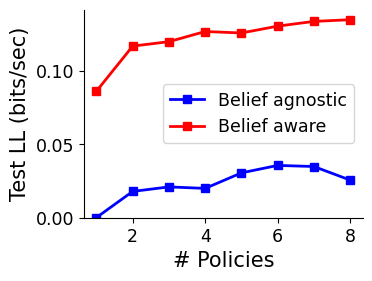

In [9]:
fig, ax = plt.subplots()
lines = []
for belief_aware in [False, True]:
    color = 'red' if belief_aware else 'blue'
    vals = np.array([lls[(n_policies, belief_aware)] for n_policies in n_policies_list])
    vals = (vals-ll_base)/np.log(2)
    h, = ax.plot(n_policies_list, vals, color=color, marker='s')
    lines.append(h) 
ax.set_xlabel('# Policies')
# ax.set_ylabel(r'$\frac{1}{T} \ln P(a_{1:T})$')
ax.set_ylabel('Test LL (bits/sec)')
ax.set_ylim([0, None])
ax.legend(lines, ['Belief agnostic', 'Belief aware'])
fig.savefig(FIG_DIR/f'HMM.likelihood_{subject_id}.svg')

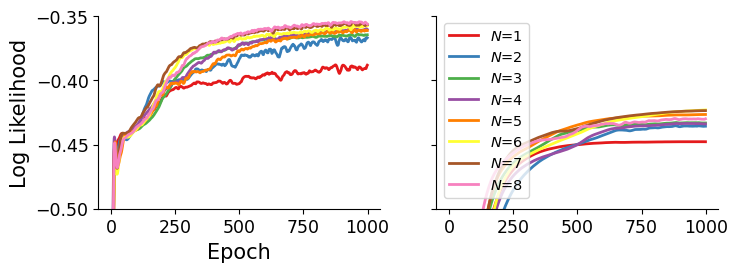

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2.5), sharex=True, sharey=True)
lines, legends = [], []
for n_policies, color in zip(n_policies_list, pi_colors):
    for i, ax in enumerate(axes):
        key = best_keys[(n_policies, i==0)]
        manager.setup(manager.configs[key])
        manager.load_ckpt(manager.ckpts[key])
        losses = torch.cat(manager.losses['val'])
        val = losses[:, 0].numpy()
        h, = ax.plot(val, color=color)
    lines.append(h)
    legends.append(f'$N$={n_policies}')
ax = axes[0]
ax.set_ylim([-0.5, -0.35])
ax.set_xlabel('Epoch')
ax.set_ylabel('Log Likelihood')
ax = axes[1]
ax.legend(lines, legends, fontsize='x-small')
plt.show()

# Inspect each belief-aware policy

In [19]:
N = 2
key = best_keys[(N, True)]
manager.setup(manager.configs[key])
manager.load_ckpt(manager.ckpts[key])
hmp = manager.hmp
hmp.load_state_dict(manager.best_state)

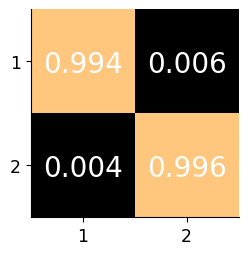

In [20]:
A = hmp.log_A.exp().data.cpu().numpy()
fig, ax = plt.subplots()
ax.imshow(A, vmin=0, vmax=1, extent=[0.5, N+0.5, N+0.5, 0.5], cmap='copper')
for i in range(N):
    for j in range(N):
        ax.text(
            j+1, i+1, '{:.3f}'.format(A[i, j]), ha='center', va='center_baseline',
            color='white', fontsize=40/N,
        )
ax.set_xlim([0.5, N+0.5]), ax.set_ylim([N+0.5, 0.5])
ax.set_xticks(np.arange(N)+1), ax.set_yticks(np.arange(N)+1)
fig.savefig(FIG_DIR/f'policy.transition_{subject_id}.svg')

In [21]:
block_ids = manager.block_ids['train']
pas, gammas, labels = {}, {}, {}
for block_id, (inputs, actions) in tqdm(
    zip(block_ids, manager.dsets['train']), total=len(block_ids), unit='block',
):
    with torch.no_grad():
        _, log_pas, log_pes, log_alphas, log_betas, log_gammas, log_xis, *_ = hmp.baum_welch(inputs[None], actions[None])
    pas[block_id] = log_pas[0].exp()
    gammas[block_id] = log_gammas[0].exp()
    labels[block_id] = hmp.viterbi_trajectory(log_pes[0])

  0%|                                                                                                         …

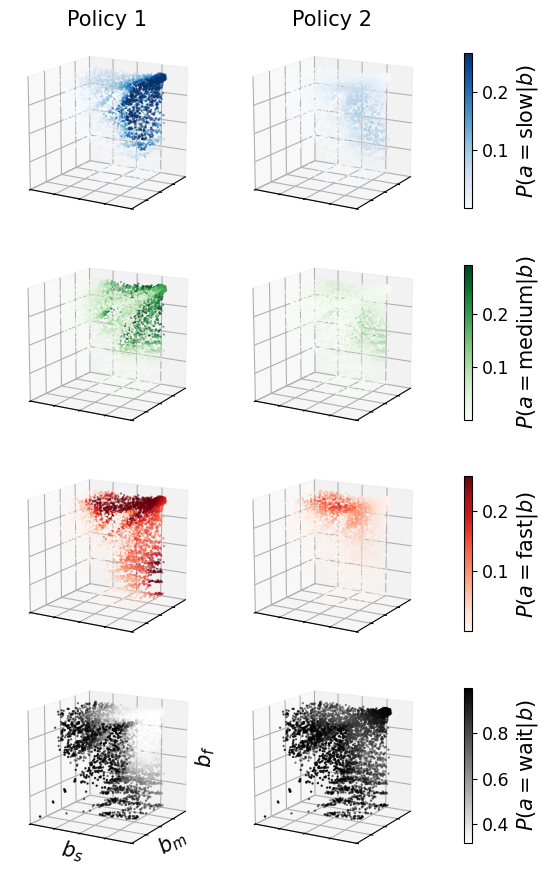

In [22]:
coords = torch.cat([manager.raw_dsets['train'][i][0] for i in range(len(block_ids))]).numpy()
vals = torch.cat([pas[block_id] for block_id in block_ids]).numpy()
idxs = rng.choice(len(coords), 5000, replace=False)
coords = coords[idxs]; vals = vals[idxs]

fig = plt.figure(figsize=(2.5*N, 9))
margin, gap = 0.05, 0.02
width = (1-2*margin-2*gap)/N
height = (1-2*margin-2*gap)/n_actions
axes = np.empty((n_actions, N), dtype=object)
labelpad = -12
cmaps = ['Blues', 'Greens', 'Reds', 'gray_r']
a_names = ['slow', 'medium', 'fast', 'wait']
for j in range(n_actions):
    cmap = cmaps[j]
    for i in range(N):
        ax = fig.add_axes(
            [0.2*margin+(width+gap)*i, margin+(height+gap)*(n_actions-j-1), width, height],
            projection='3d', elev=15,
        )
        h = ax.scatter(
            coords[:, 0], coords[:, 1], coords[:, 2], s=0.5,
            c=vals[:, i, j], cmap=cmap,
            vmin=np.quantile(vals[..., j], 0.05), vmax=np.quantile(vals[..., j], 0.95),
        )
        ax_lim = [0, 0.8]
        ax.set_xlim(ax_lim), ax.set_ylim(ax_lim), ax.set_zlim(ax_lim)
        ax.set_aspect('equal')
        ax_ticks = [0, 0.2, 0.4, 0.6]
        ax.set_xticks(ax_ticks), ax.set_yticks(ax_ticks), ax.set_zticks(ax_ticks)
        ax.set_xticklabels([]), ax.set_yticklabels([]), ax.set_zticklabels([])
        ax.zaxis.line.set_visible(False)
        for line in ax.zaxis.get_majorticklines():
            line.set_color('none')
        if i==0 and j==n_actions-1:
            ax.set_xlabel('$b_s$', labelpad=labelpad)
            ax.set_ylabel('$b_m$', labelpad=labelpad)
            ax.set_zlabel('$b_f$', labelpad=labelpad)
        if j==0:
            ax.set_title(f'Policy {i+1}', fontsize='medium')
    cax = fig.add_axes([1-1.2*margin, margin+(height+gap)*(n_actions-j-1)+0.1*height, 0.3*margin, 0.8*height])
    cbar = plt.colorbar(h, cax=cax, label=r'$P(a=\mathrm{'+a_names[j]+'}|b)$')

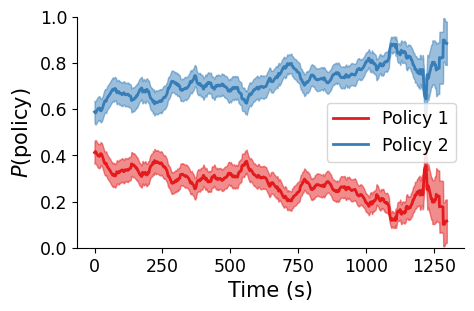

In [23]:
n_steps = max([len(labels[block_id]) for block_id in block_ids])
flags = np.full((len(block_ids), n_steps, N), fill_value=np.nan)
for i, block_id in enumerate(block_ids):
    flags[i, :len(labels[block_id])] = gammas[block_id].numpy()

fig, ax = plt.subplots(figsize=(5, 3))
lines = []
for i in range(N):
    count = (~np.isnan(flags[..., i])).astype(float).sum(axis=0)
    mask = count<10
    v_mean = np.nanmean(flags[..., i], axis=0)
    v_mean[mask] = np.nan
    v_err = np.nanstd(flags[..., i], axis=0)/count**0.5
    v_err[mask] = np.nan
    h, = ax.plot(np.arange(n_steps), v_mean, color=pi_colors[i])
    lines.append(h)
    ax.fill_between(np.arange(n_steps), v_mean-v_err, v_mean+v_err, color=pi_colors[i], alpha=0.5)
ax.legend(lines, [f'Policy {i+1}' for i in range(N)])
ax.set_xlabel('Time (s)')
ax.set_ylabel('$P$(policy)')
ax.set_ylim([0, 1])
plt.show()

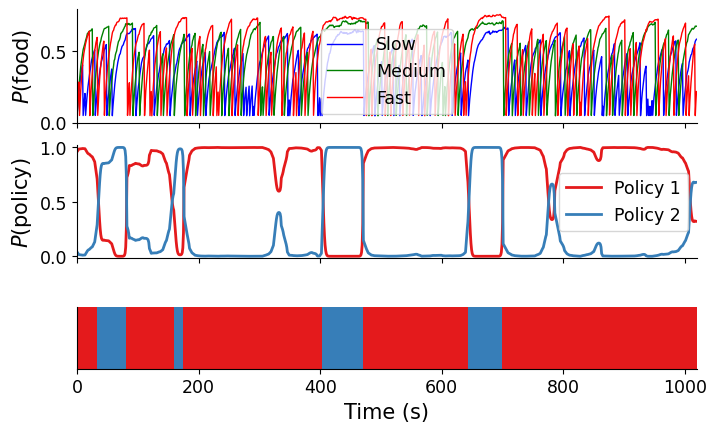

In [28]:
from matplotlib.colors import ListedColormap

b_idx = rng.choice(len(block_ids))

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
ax = axes[0]
ps_box = manager.raw_dsets['train'][b_idx][0]
lines = []
for i in range(3):
    h, = ax.plot(ps_box[:, i], color=box_colors[i], linewidth=1)
    lines.append(h)
ax.legend(lines, ['Slow', 'Medium', 'Fast'])
ax.set_ylim([0, None])
ax.set_ylabel(r'$P(\mathrm{food})$')
ax = axes[1]
lines = []
for i in range(N):
    h, = ax.plot(gammas[block_ids[b_idx]][:, i], color=pi_colors[i])
    lines.append(h)
ax.legend(lines, [f'Policy {i+1}' for i in range(N)])
ax.set_ylim([-0.02, 1.02])
ax.set_ylabel(r'$P(\mathrm{policy})$')
ax = axes[2]
h = ax.imshow(
    labels[block_ids[b_idx]][None], aspect=0.1*len(labels[block_ids[b_idx]]),
    vmin=0, vmax=N-1, cmap=ListedColormap(pi_colors[:N]))
ax.set_yticks([])
ax.set_xlabel('Time (s)')
plt.show()

# Run individual policy in simulator

In [25]:
from torch.distributions.categorical import Categorical

n_steps = 10000

probs = []
for k in range(N):
    beliefs = manager.dsets['train'][rng.choice(len(block_ids))][0]
    belief = beliefs[rng.choice(len(beliefs))][None]
    beliefs, actions = [], []
    for _ in range(n_steps):
        beliefs.append(belief)
        with torch.no_grad():
            logits, _ = hmp.action_probs(belief[None])
        logits = logits[0, 0, k]
        action = Categorical(logits=logits).sample()
        actions.append(action)
        with torch.no_grad():
            _, _, belief = model(belief, action[None], n_scale=1.)
    beliefs = torch.cat(beliefs)
    actions = torch.stack(actions)
    probs.append(np.array([(actions==a).to(torch.float).mean().item() for a in range(n_actions)]))
probs = np.stack(probs)

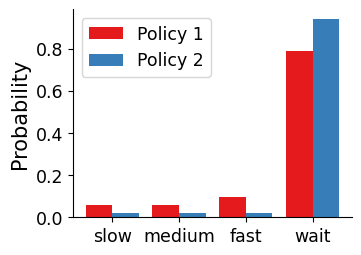

In [26]:
fig, ax = plt.subplots()
width = 0.8/N
bars = []
for k in range(N):
    h = ax.bar(np.arange(n_actions)+(2*k-N+1)/2*width, probs[k], width=width, color=pi_colors[k])
    bars.append(h)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['slow', 'medium', 'fast', 'wait'])
ax.set_ylabel('Probability')
ax.legend(bars, [f'Policy {i+1}' for i in range(N)])
plt.show()